### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prophet as fbp

Importing plotly failed. Interactive plots will not work.


In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [25]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [3]:
df = pd.read_csv('./data/AMZN.csv')

In [10]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-27,15.315000,15.5120,15.131500,15.337500,15.337500,58406000
1,2015-01-28,15.490500,15.5755,15.190000,15.195500,15.195500,61276000
2,2015-01-29,15.236500,15.6400,14.966500,15.589000,15.589000,173132000
3,2015-01-30,17.316000,17.9750,17.037001,17.726500,17.726500,477122000
4,2015-02-02,17.502501,18.2500,17.500500,18.223499,18.223499,204638000


In [6]:
df.shape

(2139, 7)

In [7]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2139.000000,2139.000000,2139.000000,2139.000000,2139.000000,2.139000e+03
mean,90.212105,91.263809,89.057423,90.175976,90.175976,8.149095e+07
std,48.489535,49.102123,47.813265,48.436046,48.436046,4.096205e+07
min,15.236500,15.512000,14.966500,15.195500,15.195500,1.762600e+07
25%,42.585751,42.731750,42.363248,42.612501,42.612501,5.505000e+07
50%,89.258003,89.942497,88.120003,89.250000,89.250000,7.015400e+07
75%,126.491001,128.674995,125.069999,126.635002,126.635002,9.499000e+07
max,187.199997,188.654007,184.839493,186.570496,186.570496,4.771220e+08


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2139 non-null   object 
 1   Open       2139 non-null   float64
 2   High       2139 non-null   float64
 3   Low        2139 non-null   float64
 4   Close      2139 non-null   float64
 5   Adj Close  2139 non-null   float64
 6   Volume     2139 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 117.1+ KB


### Step 3: Preparing Data

In [11]:
split_date = '2019-07-21'

In [15]:
df[['ds', 'y']] = df[['Date', 'Adj Close']]

In [17]:
df = df[['ds', 'y']]

In [19]:
df_train = df.loc[df['ds'] <= split_date].copy()
df_test = df.loc[df['ds'] > split_date].copy()

### Step 4: Build Model

In [13]:
model = fbp.Prophet()

In [21]:
model.fit(df_train)

18:38:55 - cmdstanpy - INFO - Chain [1] start processing
18:38:58 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
forecast = model.predict(df_test)

In [23]:
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1006,2023-07-20,108.141641,-139.528780,363.552427,-147.816964,355.441115,7.246776,7.246776,7.246776,1.294472,1.294472,1.294472,5.952304,5.952304,5.952304,0.0,0.0,0.0,115.388417
1007,2023-07-21,108.154157,-137.732636,363.553230,-147.921479,355.793581,7.125836,7.125836,7.125836,1.138373,1.138373,1.138373,5.987463,5.987463,5.987463,0.0,0.0,0.0,115.279993
1008,2023-07-24,108.191704,-141.303907,363.642645,-147.972261,356.185167,7.065573,7.065573,7.065573,1.060789,1.060789,1.060789,6.004784,6.004784,6.004784,0.0,0.0,0.0,115.257277
1009,2023-07-25,108.204219,-139.944342,365.937208,-148.035723,356.551721,7.270404,7.270404,7.270404,1.287077,1.287077,1.287077,5.983326,5.983326,5.983326,0.0,0.0,0.0,115.474623
1010,2023-07-26,108.216735,-141.413926,363.654421,-148.098491,356.918276,7.252485,7.252485,7.252485,1.302474,1.302474,1.302474,5.950011,5.950011,5.950011,0.0,0.0,0.0,115.469220


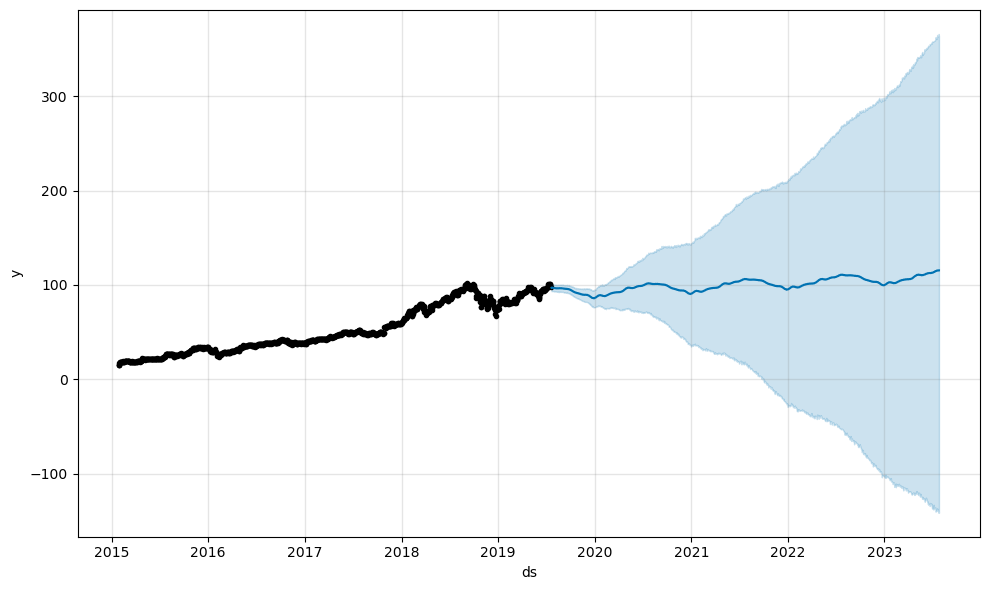

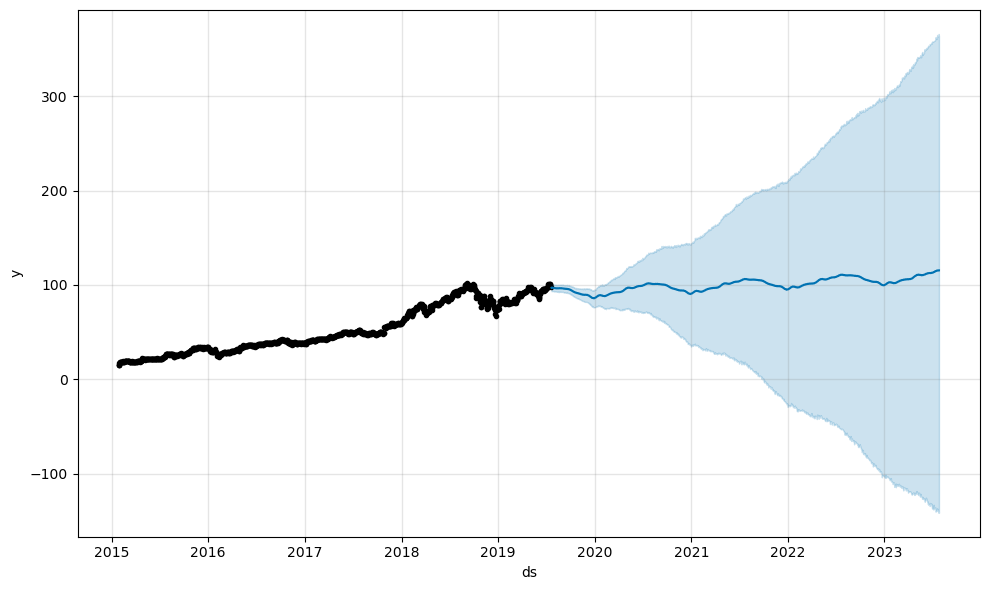

In [26]:
model.plot(forecast)

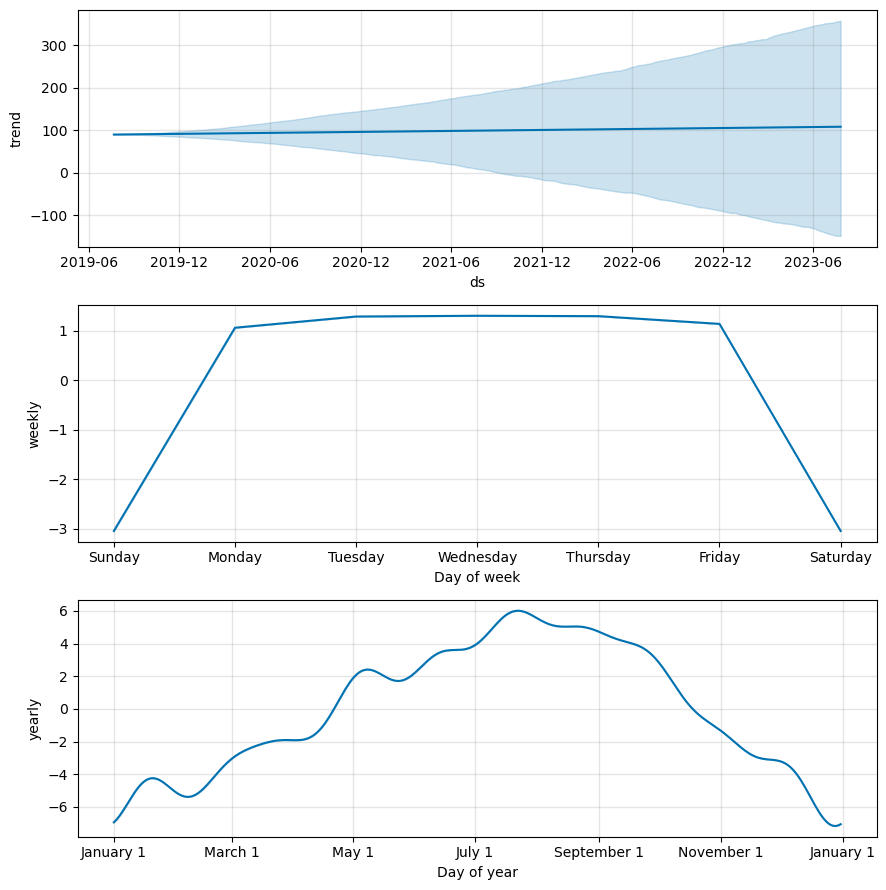

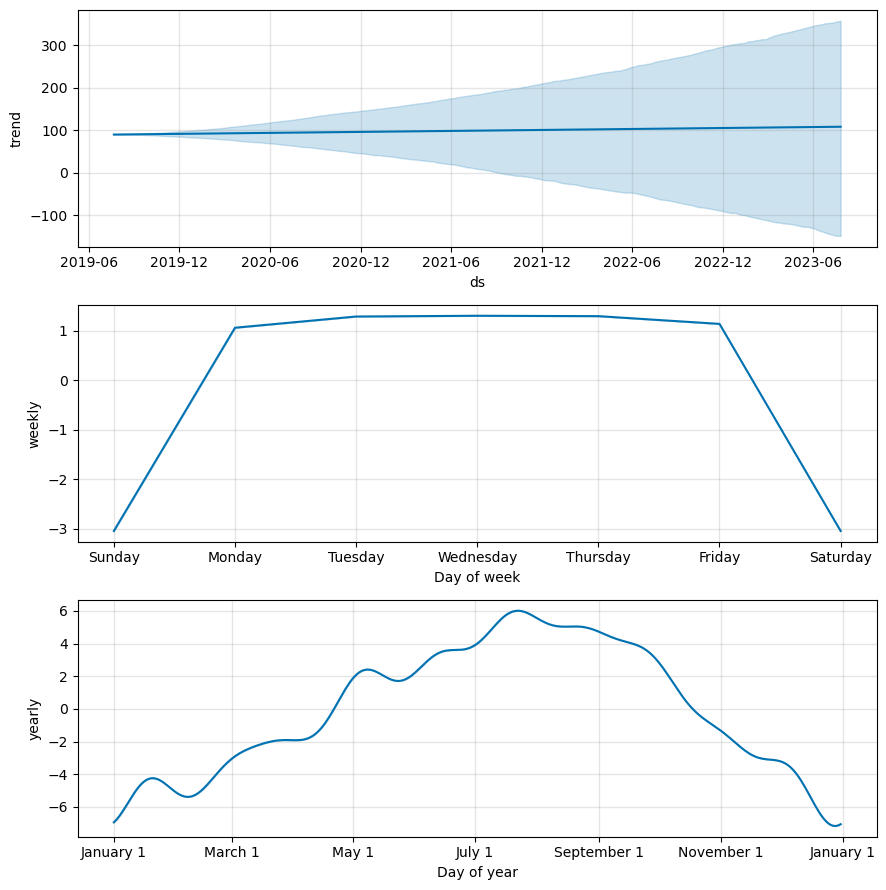

In [27]:
model.plot_components(forecast)

### Step 5: Evaluation Model

In [30]:
def mean_abs_perc_err(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [31]:
print("Mean Squared Error (MSE):", mean_squared_error(y_true = df_test["y"], y_pred = forecast['yhat']))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_true = df_test["y"], y_pred = forecast['yhat']))
print("Mean Absolute % Error (MAPE): ", mean_abs_perc_err(y_true = np.asarray(df_test["y"]), y_pred = np.asarray(forecast['yhat'])))

Mean Squared Error (MSE): 1953.8895254992644
Mean Absolute Error (MAE): 34.47221966995942
Mean Absolute % Error (MAPE):  22.712831240063295
